<h1 style="text-align:center;">37th International Summer School of the Swiss Association of Actuaries on</h1>
<h4 style="text-align:center;">“Insurance: Innovations for Products, Sustainability and Regulation”,</h4>
<p style="text-align:center;">Lausanne, 10.-14.08.2026</p>

# Day 1

## Overview
1) **_Simulation_** \
Use either a provided Python notebook or Excel sheet to simulate a path of a Brownian motion $W(t)$ on $[0, T]$, of the resulting stock price $S(t)$ (given the drift parameter $b$ and the volatility $\sigma$ and of the wealth process $X(t)$ (given a constant portfolio process $\pi$). Observe how variations of $b$ and $\sigma$ change the forms of the price paths, and how changes of $\pi$ change the wealth paths.
Do this for different time-discretizations $\Delta t$ and try to find out when the simulations break down, i.e. prices or wealth get negative due to extreme parameters and a too rough time discretization.

2) **_HJB-Equation for exponential utlity_** \
Solve the first portfolio problem with exponential utility of Lecture 3 by solving the corresponding HJB Equation in the case of $r = 0$. Interpret the solution. Is the resulting optimal strategy a reasonable one?

3) **_Log-utility and the martingale method (Bonus)_** \
Calculate the optimal portfolio and consumption strategy in the log utility case in the martingale method.

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

from common import *

## Exercise 1

Use either a provided Python notebook or Excel sheet to simulate a path of a Brownian motion $W(t)$ on $[0, T]$, of the resulting stock price $S(t)$ (given the drift parameter $b$ and the volatility $\sigma$ and of the wealth process $X(t)$ (given a constant portfolio process $\pi$). Observe how variations of $b$ and $\sigma$ change the forms of the price paths, and how changes of $\pi$ change the wealth paths.
Do this for different time-discretizations $\Delta t$ and try to find out when the simulations break down, i.e. prices or wealth get negative due to extreme parameters and a too rough time discretization.

### Simulating Brownian Motion

A one-dimensional Brownian motion with drift $\mu$ and diffusion $\sigma$ satisfies the SDE
$$\mathrm{d}W_t = \mu \mathrm{d}t + \sigma \mathrm{d}W^\mathrm{std}_t$$
where $W^\mathrm{std}$ is a standard Brownian motion.

Complete the following function that simulates ```params.num_paths``` paths of a one-dimensional Brownian motion with drift ```mu``` and diffusion ```sigma``` up to a time ```params.time_horizon``` using ```params.time_steps``` time steps via the recursive relationship
$$W_{t_{n+1}} \approx W_{t_n} + \mu \Delta t + \sigma \sqrt{\Delta t} Z, \quad Z \sim \mathcal{N}(0,1) .$$
Avoid loops to make computation more efficient. Functions like ```np.linspace``` and ```np.cumsum``` may help.

In [2]:
def generate_brownian_path(mu: float = 0, sigma: float = 1, params: SDESimulationParameters = SDESimulationParameters()) -> SDEOutput:
    """
    Generate a Brownian motion path using the Euler-Maruyama scheme.
    """
    # Set seed for reproducibility
    np.random.seed(params.seed)

    # Initialize the Brownian path array
    brownian_path = np.zeros((params.time_steps + 1, params.num_paths))

    # Generate the Brownian motion increments
    dt = params.dt
    dW = np.random.normal(loc=0.0, scale=np.sqrt(dt), size=(params.time_steps, params.num_paths))

    t  = np.linspace(0, params.time_horizon, params.time_steps + 1)
    W  = np.cumsum(dW, axis=0)

    # Apply the Euler-Maruyama method to generate the Brownian path
    brownian_path[1:,:] = mu * t[1:, np.newaxis] + sigma * W

    return SDEOutput(time_grid=t, paths={'W': brownian_path, 'dW': dW})

### Validation of Brownian Motion Simulation

#### Numerical Validation

We validate the simulation results by comparing empirical statistics against theoretical predictions:

1. **Initial Condition**: Verify that all paths start at 0, as required by the definition of Brownian motion.

2. **Mean**: The empirical mean of terminal values should match the theoretical mean $\mathbb{E}[W_T] = \mu T$.

3. **Standard Deviation**: The empirical standard deviation should match $\sqrt{\text{Var}(W_T)} = \sigma\sqrt{T}$.

4. **Quadratic Variation**: The mean quadratic variation at time $T$ should equal $\sigma^2 T$, which verifies that the incremental structure of the simulation is correct.

In [3]:
T     = 1.0
N     = 250
M     = 50_000
mu    = -1
sigma = 0.2

test_params = SDESimulationParameters(time_horizon=T, time_steps=N, num_paths=M)

out             = generate_brownian_path(mu=mu, sigma=sigma, params=test_params)
path_statistics = compute_test_statistics(out.paths['W'][-1, :])
qv_statistics   = compute_test_statistics(out.quadratic_variation['W'][-1, :])

In [4]:
print(path_statistics, "\n")

check_condition("Starts at 0", np.isclose(out.paths['W'][0, :], 0.0).all())
check_value("Mean", path_statistics.mean, T*mu, abs_tol=1e-3, rel_tol=1e-6)
check_value("Std Dev", path_statistics.std_dev, sigma*np.sqrt(T), abs_tol=1e-3, rel_tol=1e-6)
check_value("Quadratic Variation at T", qv_statistics.mean, sigma**2*T + mu**2*T*test_params.dt, abs_tol=1e-3, rel_tol=1e-6) # mu**2*T*test_params.dt corrects for the drift term in the (discretized) quadratic variation

Mean ± StdDev: -1.000632 ± 0.200104,
(Min) -1.789335 <-- 1.603328 --> -0.186007 (Max)
Quantiles: 
|5%: -1.330795|25%: -1.135814|50%: -0.999979|75%: -0.865727|95%: -0.674913| 

✅ Starts at 0: Condition is True
✅ Mean: -1.000632 ≈ -1.000000
✅ Std Dev: 0.200104 ≈ 0.200000
✅ Quadratic Variation at T: 0.044009 ≈ 0.044000


#### Visual Validation

The simulation is validated visually by:

1. **Path Visualization**: Plotting a sample of simulated Brownian motion paths against the time grid shows whether paths follow expected drift behavior and volatility characteristics.

2. **Distribution Comparison**: The histogram of terminal values $W_T$ is overlaid with the theoretical normal distribution $\mathcal{N}(\mu T, \sigma^2 T)$. A good match confirms that the distribution of outcomes follows the expected Gaussian shape.

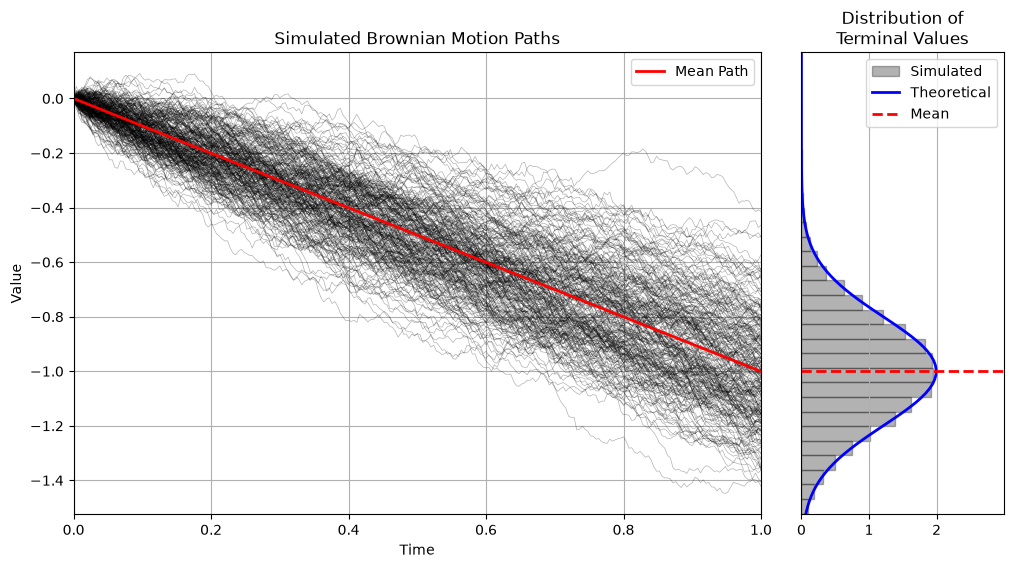

In [5]:
theoretical_distribution = lambda x: 1/(sigma*np.sqrt(2*np.pi)) * np.exp(-0.5*((x - mu*T)/(sigma*np.sqrt(T)))**2)
theoretical_mean = mu*T

plot_SDE_paths(out, plot_component='W', num_plot_paths=250, title="Simulated Brownian Motion Paths", xlabel="Time", ylabel="Value", theoretical_distribution=theoretical_distribution, theoretical_mean=theoretical_mean)

### From Brownian motion to a financial market

We now consider a Black-Scholes market consisting of a risk-free bond $B_t$ and one risky stock $S_t$:

$$\mathrm{d}B_t = rB_t \,\mathrm{d}t, \qquad \mathrm{d}S_t = bS_t \,\mathrm{d}t + \sigma S_t \,\mathrm{d}W_t .$$

Here:

- $r$ is the risk-free interest rate,
- $b$ is the stock drift,
- $b-r$ is the risk premium,
- $\sigma$ is the stock volatility.

In the `FinancialMarket` class, these quantities are represented by

$$b = r + \texttt{risk\_premium} .$$

Using the Euler-Maruyama scheme, the dynamics are approximated by

$$B_{t_{n+1}} = B_{t_n}(1+r\Delta t) ,$$

and

$$S_{t_{n+1}} = S_{t_n} \left( 1 + b\Delta t + \sigma\Delta W_n \right), \qquad \Delta W_n\sim\mathcal N(0,\Delta t) .$$

The quality of this approximation depends on the time-step size $\Delta t$. In particular, a rough discretization can produce negative simulated stock prices even though the continuous-time Black-Scholes stock price is always positive. We will investigate this more closely later.

In [6]:
def simulate_market(initial_stock_price: float, market_params: FinancialMarket, sde_params: SDESimulationParameters) -> SDEOutput:
    """
    Simulate market dynamics using the Euler-Maruyama scheme.
    """
    
    # Initialize the bond and stock price arrays
    bond_prices = np.zeros((sde_params.time_steps + 1, sde_params.num_paths))
    stock_prices = np.zeros((sde_params.time_steps + 1, sde_params.num_paths))

    # Set initial prices
    bond_prices[0, :] = 1.0  # Assuming the bond starts at 1.0
    stock_prices[0, :] = initial_stock_price

    # Generate the Brownian motion increments
    out = generate_brownian_path(mu=0, sigma=1, params=sde_params)
    dt  = sde_params.dt
    dW  = out.paths['dW']

    # Simulate the market dynamics
    # dB_t = r * B_t dt                     -> B_n = B_{n-1} * (1 + r * dt)
    # dS_t = mu * S_t dt + sigma * S_t dW_t -> S_n = S_{n-1} * (1 + mu * dt + sigma * dW_n)
    t   = np.linspace(0, sde_params.time_horizon, sde_params.time_steps + 1)
    B   = np.cumprod(np.repeat(1 + market_params.risk_free_rate * dt, sde_params.time_steps).reshape(-1, 1))
    S   = stock_prices[0, :] * np.cumprod(1 + market_params.drift * dt + market_params.volatility * dW, axis=0)

    # Store the bond and stock prices
    bond_prices[1:, :] = np.repeat(B[:, np.newaxis], sde_params.num_paths, axis=1)
    stock_prices[1:, :] = S

    return SDEOutput(time_grid=t, paths={'bond': np.repeat(B[:, np.newaxis], sde_params.num_paths, axis=1), 'stock': stock_prices})

#### Validation of the market simulation

The bond is deterministic. Its exact value at time $T$ is

$$B_T = \mathrm{e}^{rT}.$$

For the stock, the continuous-time Black-Scholes model implies

$$S_T = S_0 \exp\left[ \left( b - \frac{1}{2}\sigma^2 \right) T + \sigma W_T \right] .$$

Consequently, $S_T$ is lognormally distributed and

$$\mathbb{E}[S_T] = S_0 \mathrm{e}^{bT} .$$

We compare the simulated terminal values with this theoretical lognormal distribution. If the time discretization is sufficiently fine, the empirical mean and distribution should be close to their theoretical counterparts.

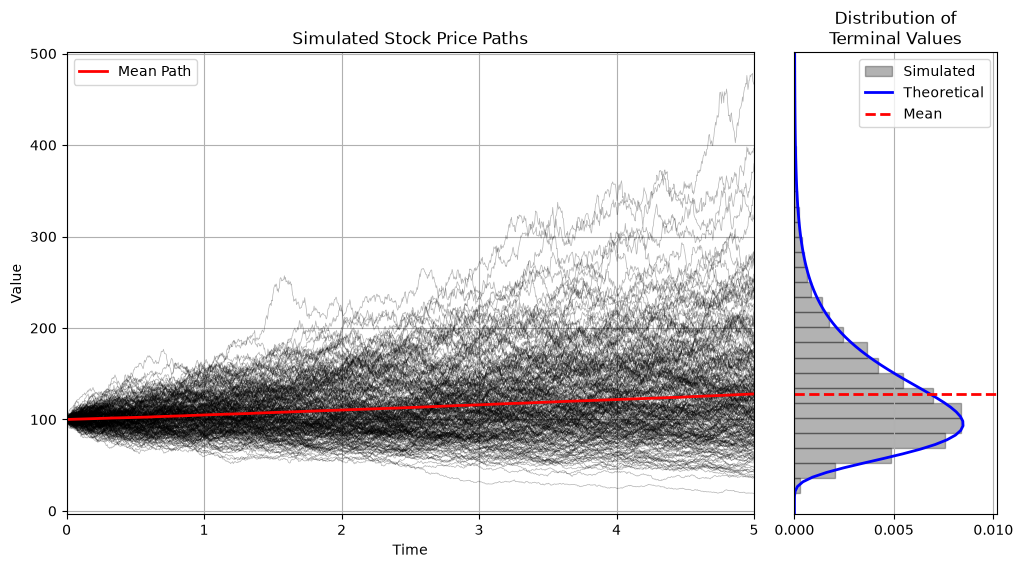

In [7]:
# Test market simulation
M     = 10_000
T     = 5
S0    = 100
r     = 0.025
drift = 0.05
vola  = 0.2

market_params = FinancialMarket(risk_free_rate=r, risk_premium=drift - r, volatility=vola)
sde_params = SDESimulationParameters(time_horizon=T, time_steps=250*T, num_paths=M)
out = simulate_market(initial_stock_price=S0, market_params=market_params, sde_params=sde_params)

theoretical_mean         = S0 * np.exp(drift*T)
theoretical_distribution = lambda x: lognormal_pdf(x, mu=np.log(S0) + (drift - 0.5*vola**2)*T, sigma=vola*np.sqrt(T))

plot_SDE_paths(out, plot_component='stock', num_plot_paths=250, title="Simulated Stock Price Paths", xlabel="Time", ylabel="Value", theoretical_distribution=theoretical_distribution, theoretical_mean=theoretical_mean)

### Exact solution and discretization error

For constant model parameters, the Black-Scholes equations have the explicit solutions

$$B_t = \mathrm{e}^{rt}$$

and

$$S_t = S_0 \exp\left[\left( b - \frac{1}{2}\sigma^2 \right)t + \sigma W_t \right] .$$

The exact stock-price solution is strictly positive. By contrast, the Euler-Maruyama update

$$S_{t_{n+1}} = S_{t_n} \left( 1 + b\Delta t + \sigma\Delta W_n \right)$$

becomes negative whenever

$$1 + b\Delta t + \sigma\Delta W_n < 0 .$$

This happens with probability

$$\mathbb{P}\left( \Delta W_n < -\frac{1 + b\Delta t}{\sigma} \right) = \Phi\left( -\frac{1 + b\Delta t}{\sigma \sqrt{\Delta t}} \right) ,$$

where $\Phi$ is the standard normal cumulative distribution function. For a fixed time step $\Delta t$, this probability is non-negligible for sufficiently negative $b$ or sufficiently large $\sigma$. This is a numerical discretization effect rather than a property of the continuous-time model. Comparing the Euler-Maruyama paths with the exact paths illustrates how the approximation improves as $\Delta t$ decreases.

Thus, by using the exact solution

$$S_t = S_0 \exp\left[\left( b - \frac{1}{2}\sigma^2 \right)t + \sigma W_t \right] ,$$

we can avoid the issue of negative stock prices in simulations, ensuring that the simulated paths remain consistent with the theoretical properties of the Black-Scholes model.

In [8]:
def simulate_market_dynamics_exact(initial_stock_price: float, market_params: FinancialMarket, sde_params: SDESimulationParameters) -> SDEOutput:
    """
    Simulate market dynamics using the exact method.
    """

    # Generate the driving Brownian motion path
    out = generate_brownian_path(0, 1, sde_params)

    t = out.time_grid
    W = out.paths['W']

    # Compute the bond and stock prices using the exact solution
    bond_price = np.exp(market_params.risk_free_rate * t[:, np.newaxis])
    stock_price = initial_stock_price * np.exp((market_params.drift - 0.5 * market_params.volatility**2) * t[:, np.newaxis] + market_params.volatility * W)

    return SDEOutput(time_grid=t, paths={'bond': bond_price, 'stock': stock_price})

Probability of negative stock price for b=-1, sigma=0.75, dt=0.3333333333333333:  6.18%


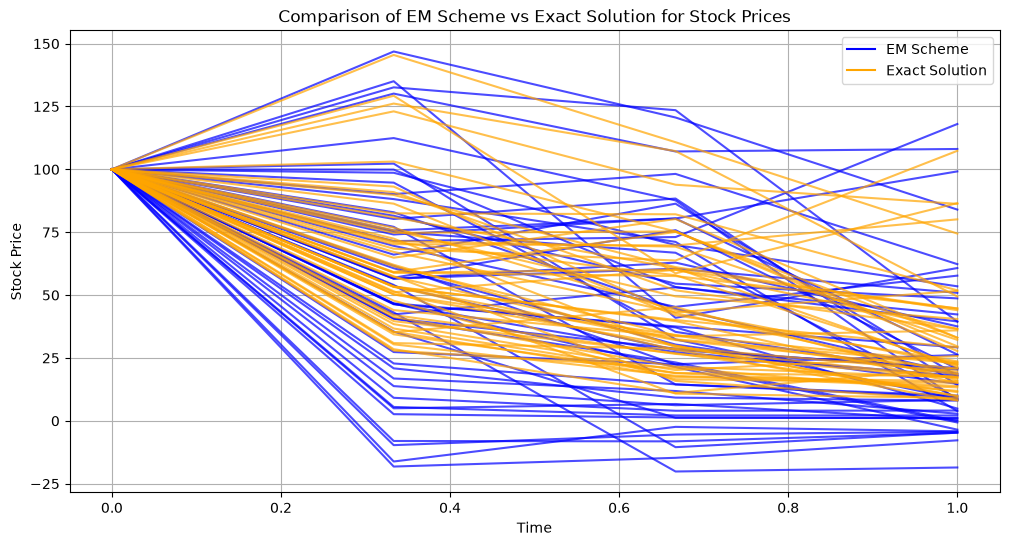

In [9]:
M     = 50
dt    = 0.33
drift = -1
vola  = 0.75

market_params = FinancialMarket(risk_free_rate=0, risk_premium=drift, volatility=vola)
sde_params    = SDESimulationParameters(time_horizon=1, time_steps=int(1/dt), num_paths=M)

probability_of_negative_stock_price = lambda b, sigma, dt: norm.cdf(- (1 + b * dt) / (sigma * np.sqrt(dt)))

print(f"Probability of negative stock price for b={drift}, sigma={vola}, dt={sde_params.dt}: {100 * probability_of_negative_stock_price(market_params.risk_premium, market_params.volatility, sde_params.dt) : .2f}%")

out_em    = simulate_market(initial_stock_price=100, market_params=market_params, sde_params=sde_params)
out_exact = simulate_market_dynamics_exact(initial_stock_price=100, market_params=market_params, sde_params=sde_params)

compare_paths([out_em, out_exact], plot_component='stock', num_plot_paths=M, title="Comparison of EM Scheme vs Exact Solution for Stock Prices", xlabel="Time", ylabel="Stock Price", colororder=['blue', 'orange'], labels=['EM Scheme', 'Exact Solution'])

### When does the Euler-Maruyama simulation break down?

Recall that the Euler-Maruyama update can become negative if

$$1 + b\Delta t + \sigma\Delta W_n < 0.$$

This becomes more likely when:

- the time step $\Delta t$ is large,
- volatility $\sigma$ is large,
- the drift $b$ is strongly negative.

The following experiment randomly samples combinations of drift, volatility, and time-step size. A point is recorded whenever at least one simulated Euler path becomes negative at any time. The color and size of each point indicate the proportion of degenerate paths per parameter combination. The resulting 3D scatter plot illustrates the regions in parameter space where the Euler-Maruyama simulation is likely to break down. As expected, the breakdown occurs for large $\sigma$, negative $b$, and large $\Delta t$.

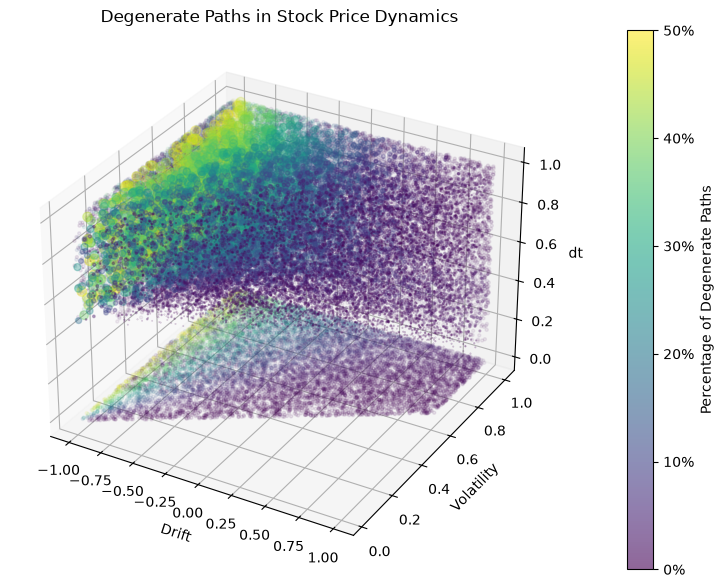

In [10]:
visualize_degenerate_paths(simulate_market, M=25_000, M_inner=1_000, drift_range=(-1, 1), vola_range=(0, 1), dt_range=(1e-3, 1))

### Simulating the wealth process

Let $u_t$ denote the monetary amount invested in the stock. The remaining amount $X_t - u_t$ is invested in the bond. The self-financing wealth process therefore satisfies

$$\mathrm{d}X_t = \left[ rX_t + u_t(b-r) \right]\mathrm{d}t + u_t\sigma \,\mathrm{d}W_t .$$

We consider two different investment conventions.

#### Constant fraction of wealth

If a constant fraction $\pi$ of wealth is invested in the stock, then

$$u_t = \pi X_t.$$

The wealth process satisfies

$$\frac{\mathrm{d}X_t}{X_t} = \left[ r + \pi(b-r) \right]\mathrm{d}t + \pi\sigma \,\mathrm{d}W_t ,$$

with explicit solution

$$X_t = X_0 \exp\left[\left( r + \pi(b-r) - \frac{1}{2}\pi^2\sigma^2 \right)t + \pi\sigma W_t \right].$$

Thus the amount invested in the stock changes whenever wealth changes.

#### Constant nominal amount

If a fixed monetary amount $\xi$ is invested in the stock, then

$$u_t = \xi.$$

For $r=0$, the wealth process has the explicit solution

$$X_t = X_0 + \xi bt + \xi\sigma W_t.$$

Here the stock exposure is independent of current wealth. Unlike the constant-fraction solution, this wealth process is Gaussian and can become negative.

In [11]:
def simulate_wealth(initial_wealth: float, constant_investment: float, investment_strategy: InvestmentType, market_params: FinancialMarket, sde_params: SDESimulationParameters) -> SDEOutput:
    """
    Simulate wealth dynamics based on the chosen investment strategy.
    """

    # Initialize the wealth array
    wealth = np.zeros((sde_params.time_steps + 1, sde_params.num_paths))
    
    # Set initial prices
    wealth[0, :] = initial_wealth
    
    # Generate the Brownian motion increments
    out = generate_brownian_path(mu=0, sigma=1, params=sde_params)
    dt  = sde_params.dt
    dW  = out.paths['dW']

    # Simulate the market dynamics
    match investment_strategy:
        case InvestmentType.ConstantFraction:
            u = lambda x: constant_investment * x  # Investment is a fraction of current wealth
        case InvestmentType.ConstantNominal:
            u = lambda x: constant_investment      # Investment is a fixed nominal amount
        case _:
            raise ValueError("Invalid investment strategy. Choose either 'ConstantFraction' or 'ConstantNominal'.")

    # Simulate wealth dynamics based on the chosen investment strategy
    t = np.linspace(0, sde_params.time_horizon, sde_params.time_steps + 1)
    for i in range(1, sde_params.time_steps + 1):
        current_wealth = wealth[i - 1, :]
        investment_amount = u(current_wealth)
                
        # Update wealth based on the market dynamics
        # dX_t = (rX_t + u_t * (mu - r)) dt + u_t * sigma dW_t
        wealth[i, :] = current_wealth + (market_params.risk_free_rate * current_wealth + investment_amount * (market_params.drift - market_params.risk_free_rate)) * dt + investment_amount * market_params.volatility * dW[i - 1, :]

    return SDEOutput(time_grid=t, paths={'X': wealth})

#### Constant fraction versus constant nominal investment

To make the strategies comparable, we choose the fixed nominal investment such that both strategies have the same stock exposure initially:

$$\xi = \pi X_0 .$$

At $t=0$, both strategies therefore invest the same amount in the stock. Afterwards, their behavior differs:

- The constant-fraction strategy increases its stock exposure when wealth rises and reduces it when wealth falls.
- The constant-nominal strategy continuously rebalances back to the fixed monetary amount $\xi$.

The following simulation shows how this difference in rebalancing affects the resulting wealth paths.

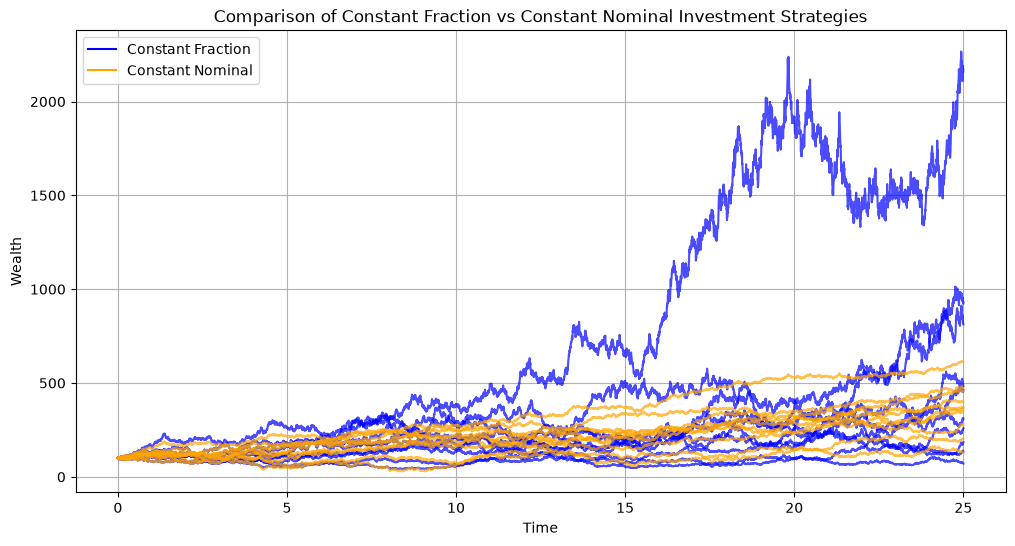

In [12]:
M     = 10
T     = 25
X0    = 100
r     = 0.025
drift = 0.08
vola  = 0.25

market_params = FinancialMarket(risk_free_rate=r, risk_premium=drift - r, volatility=vola)
sde_params = SDESimulationParameters(time_horizon=T, time_steps=250*T, num_paths=M)

merton_fraction = (drift - r) / (vola**2)

out_constant_fraction = simulate_wealth(initial_wealth=X0, constant_investment=merton_fraction, investment_strategy=InvestmentType.ConstantFraction, market_params=market_params, sde_params=sde_params)
out_constant_nominal  = simulate_wealth(initial_wealth=X0, constant_investment=merton_fraction*X0, investment_strategy=InvestmentType.ConstantNominal, market_params=market_params, sde_params=sde_params)

compare_paths([out_constant_fraction, out_constant_nominal], plot_component='X', num_plot_paths=M, title="Comparison of Constant Fraction vs Constant Nominal Investment Strategies", xlabel="Time", ylabel="Wealth", colororder=['blue', 'orange'], labels=['Constant Fraction', 'Constant Nominal'])

### Sensitivity to model and strategy parameters

We next investigate how the simulated paths react to changes in the model parameters and the investment strategy.

#### Drift and volatility

The drift mainly controls the average direction of the stock-price paths, while volatility controls their dispersion:

- A larger positive drift tends to produce increasing stock prices.
- A negative drift tends to produce decreasing stock prices.
- A larger volatility creates a wider range of possible outcomes.
- High volatility also increases the probability that the Euler scheme produces negative values.

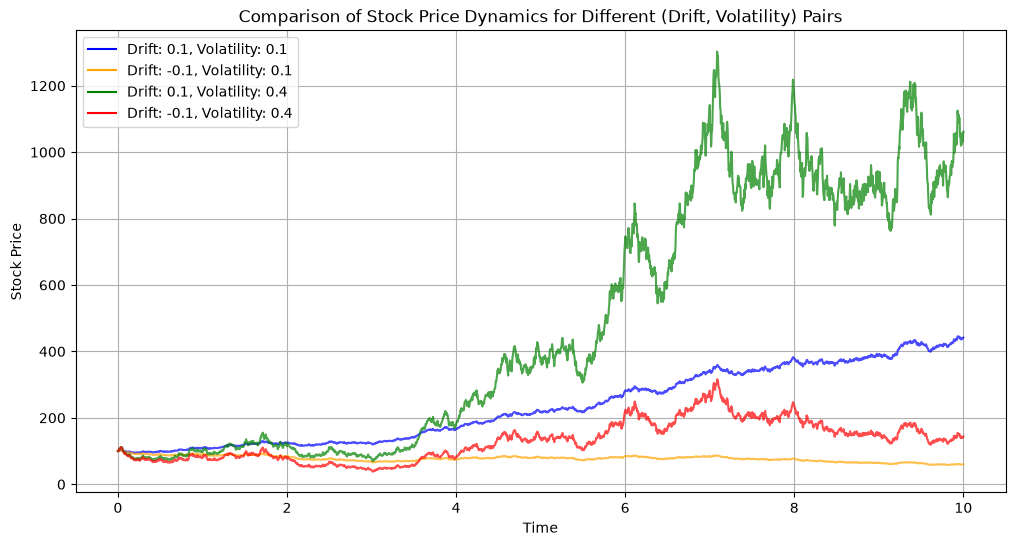

In [13]:
# compare paths for different pairs of (drift, volatility) values
params_list = [
    (0.1, 0.1),
    (-0.1, 0.1),
    (0.1, 0.4),
    (-0.1, 0.4)
]

out_list = []
for drift, vola in params_list:
    market_params = FinancialMarket(risk_free_rate=0, risk_premium=drift, volatility=vola)
    sde_params = SDESimulationParameters(time_horizon=10, time_steps=2500, num_paths=1)
    out = simulate_market(initial_stock_price=100, market_params=market_params, sde_params=sde_params)
    out_list.append(out)

compare_paths(out_list, plot_component='stock', num_plot_paths=1, title="Comparison of Stock Price Dynamics for Different (Drift, Volatility) Pairs", xlabel="Time", ylabel="Stock Price", colororder=['blue', 'orange', 'green', 'red'], labels=[f"Drift: {drift}, Volatility: {vola}" for drift, vola in params_list])

#### Investment fraction

The portfolio fraction $\pi$ determines both the excess expected return and the volatility of wealth:

$$\frac{\mathrm{d}X_t}{X_t} = \left[r+\pi(b-r)\right]\mathrm{d}t + \pi\sigma\,\mathrm{d}W_t .$$

A larger $\pi$ increases the investor's exposure to both the stock's risk premium and its risk.

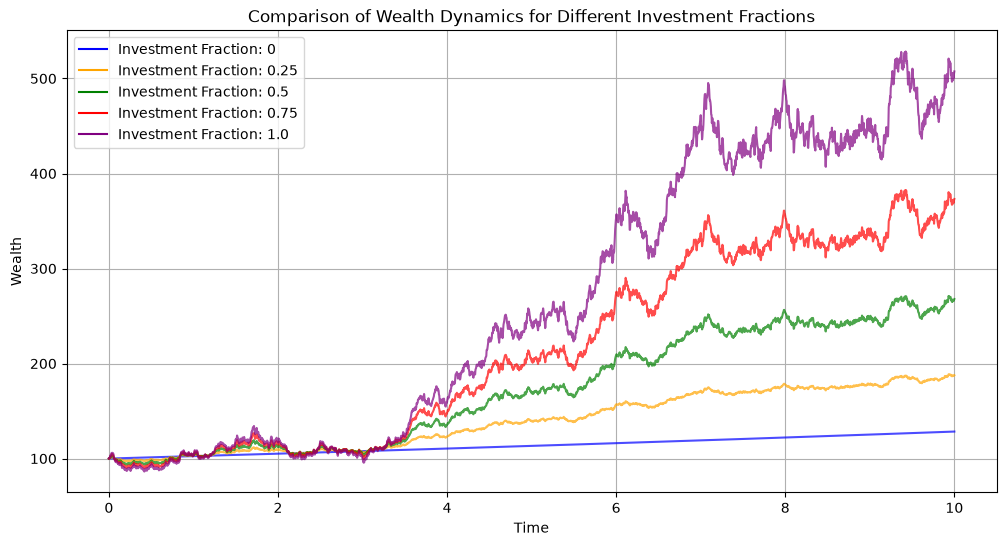

In [14]:
# compare wealth paths for different values of pi
risky_fractions = [0, 0.25, 0.5, 0.75, 1.0]

out_list = []
for pi in risky_fractions:
    market_params = FinancialMarket(risk_free_rate=0.025, risk_premium=0.05, volatility=0.2)
    sde_params = SDESimulationParameters(time_horizon=10, time_steps=2500, num_paths=1)
    out = simulate_wealth(initial_wealth=100, constant_investment=pi, investment_strategy=InvestmentType.ConstantFraction, market_params=market_params, sde_params=sde_params)
    out_list.append(out)

compare_paths(out_list, plot_component='X', num_plot_paths=1, title="Comparison of Wealth Dynamics for Different Investment Fractions", xlabel="Time", ylabel="Wealth", colororder=['blue', 'orange', 'green', 'red', 'purple'], labels=[f"Investment Fraction: {pi}" for pi in risky_fractions])

### Conclusions from the simulation experiment

The numerical experiments illustrate several important features of continuous-time portfolio models:

1. Brownian increments have the expected mean, variance, and quadratic variation.
2. The exact Black-Scholes stock price is lognormally distributed and remains positive.
3. Euler-Maruyama approximates the continuous-time dynamics, but it can produce negative prices when the time discretization is too rough relative to the model parameters.
4. Drift controls the average direction of the paths, while volatility controls their dispersion.
5. A constant-fraction strategy and a constant-nominal strategy can start with the same stock exposure but produce very different wealth dynamics.
6. Numerical breakdown is a property of the discretization and should not be confused with the behavior of the underlying continuous-time model.

## Exercise 2

Solve the first portfolio problem with exponential utility of Lecture 3 by solving the corresponding HJB Equation in the case of $r = 0$. Interpret the solution. Is the resulting optimal strategy a reasonable one?

### Solving the HJB equation for exponential utility in absence of interest ($r = 0$)

Let $\xi_t = \pi_t X_t$ denote the **amount of money** invested in the stock. When $r=0$, the wealth dynamics are

$$\mathrm{d}X_t = \xi_t b \,\mathrm{d}t + \xi_t\sigma \,\mathrm{d}W_t, \qquad X_0 = x ,$$

and the objective is

$$V(t,x) = \sup_\xi \mathbb{E}_{t,x}\!\left[ 1 - \mathrm{e}^{-\lambda X_T} \right], \qquad \lambda>0 .$$

The HJB equation is

$$0 = V_t + \sup_{\xi \in \mathbb{R}} \left\{ b\xi V_x + \frac{1}{2}\sigma^2\xi^2 V_{xx} \right\}, \qquad V(T,x) = 1 - \mathrm{e}^{-\lambda x} .$$

Because the terminal utility is exponential, try

$$V(t,x) = 1 - \exp\{-\lambda x - k(t)\}, \qquad k(T) = 0 .$$

Its derivatives are

$$V_x = \lambda \mathrm{e}^{-\lambda x - k(t)}, \qquad V_{xx} = -\lambda^2\mathrm{e}^{-\lambda x - k(t)}, \qquad V_t = k'(t)\mathrm{e}^{-\lambda x - k(t)} .$$

For fixed $(t,x)$, the expression to maximize is

$$\mathrm{e}^{-\lambda x - k(t)} \left(\lambda b\xi - \frac{1}{2}\lambda^2\sigma^2\xi^2 \right) .$$

This is a strictly concave quadratic in $\xi$. Its first-order condition gives

$$\lambda b - \lambda^2\sigma^2\xi^\ast = 0 ,$$

and hence

$$\boxed{\xi_t^\ast = \frac{b}{\lambda\sigma^2} .}$$

Substitution into the HJB equation gives

$$k'(t) + \frac{1}{2}\frac{b^2}{\sigma^2} = 0, \qquad k(T) = 0 ,$$

so

$$k(t) = \frac{1}{2}\frac{b^2}{\sigma^2}(T-t) .$$

Therefore, the value function is

$$\boxed{V(t,x) = 1 - \exp\left( -\lambda x - \frac{1}{2}\frac{b^2}{\sigma^2}(T-t) \right) .}$$

The optimally controlled wealth process is

$$\mathrm{d}X_t^\ast = \frac{b^2}{\lambda\sigma^2} \,\mathrm{d}t
 + \frac{b}{\lambda\sigma} \,\mathrm{d}W_t ,$$

and consequently

$$\boxed{X_t^\ast = x + \frac{b^2}{\lambda\sigma^2}t
 + \frac{b}{\lambda\sigma}W_t .}$$

More generally, if the problem starts at time $t$ with wealth $x$, then for $s \in [t,T]$,

$$X_s^\ast = x + \frac{b^2}{\lambda\sigma^2}(s-t)
 + \frac{b}{\lambda\sigma}(W_s - W_t) .$$

### Interpretation

- Exponential utility has constant absolute risk aversion $\lambda$, so the investor chooses a constant **dollar amount**, rather than a constant fraction of wealth.
- The position is independent of current wealth and of the remaining investment horizon.
- It increases with the risk premium $b$, decreases with variance $\sigma^2$, and decreases with absolute risk aversion $\lambda$.
- If $b<0$, the formula prescribes a constant short position; if $b=0$, it prescribes no stock investment.

The strategy is internally reasonable in the frictionless model with unrestricted borrowing, short selling, and negative wealth. It is less reasonable as a literal real-world policy: a poor and a wealthy investor hold the same dollar position, wealth is Gaussian and can become negative, and the risky fraction $\xi_t^\ast/X_t^\ast$ can become arbitrarily large near zero wealth. With solvency or leverage constraints, the unconstrained formula generally ceases to be admissible and must be modified.

In [15]:
T                 = 10.0
x                 = 1.0
abs_risk_aversion = 0.25

market = FinancialMarket(risk_free_rate=0.0, risk_premium=0.05, volatility=0.25)

# Optimal and suboptimal constant monetary investments
xi_star = market.risk_premium / (abs_risk_aversion * market.volatility**2)
xi_sub  = 2 * xi_star

print(f"Initial wealth        :  x  = {x:.4f}")
print(f"Optimal investment    : xi* = {xi_star:.4f}")
print(f"Suboptimal investment : xi  = {xi_sub:.4f}")
print(f"E[U(X_T)] optimal     :       {expected_utility_exact(x, T, xi_star, abs_risk_aversion, market):.6f}")
print(f"E[U(X_T)] suboptimal  :       {expected_utility_exact(x, T, xi_sub, abs_risk_aversion, market):.6f}")

Initial wealth        :  x  = 1.0000
Optimal investment    : xi* = 3.2000
Suboptimal investment : xi  = 6.4000
E[U(X_T)] optimal     :       0.362372
E[U(X_T)] suboptimal  :       0.221199


### Numerical verification of the optimal strategy

To see how the expected utility varies with the constant investment $\xi$, we compare the analytical formula, obtained using the moment-generating function of a normal random variable, together with a Monte Carlo simulation. For a constant monetary investment $\xi$ and $r=0$,

$$X_T^\xi = x + \xi bT + \xi \sigma W_T .$$

Because $X_T^\xi$ is normally distributed, its expected exponential utility is

$$\mathbb E[U(X_T^\xi)] = 1 - \exp\left( -\lambda x - \lambda\xi bT + \frac{1}{2}\lambda^2\xi^2\sigma^2T \right) $$

which can be verified by computing the moment-generating function of a normal random variable. Completing the square in the exponent gives

$$\mathbb E[U(X_T^\xi)] = 1 - \exp\left[ -\lambda x - \frac{1}{2}\frac{b^2}{\sigma^2}T + \frac{1}{2}\lambda^2\sigma^2T(\xi-\xi^\ast)^2 \right] ,$$

where

$$\xi^\ast = \frac{b}{\lambda\sigma^2} .$$

The squared term is minimized at $\xi = \xi^\ast$. Since $1 - \exp(z)$ is decreasing in $z$, $\xi^\ast$ is the unique maximizer of expected utility. Unsurprisingly, this is the same optimal investment amount obtained from the HJB equation.

We verify this result for $x = 1$ and $T = 1$ using both the analytical formula and a Monte Carlo simulation with pointwise 95% confidence intervals.

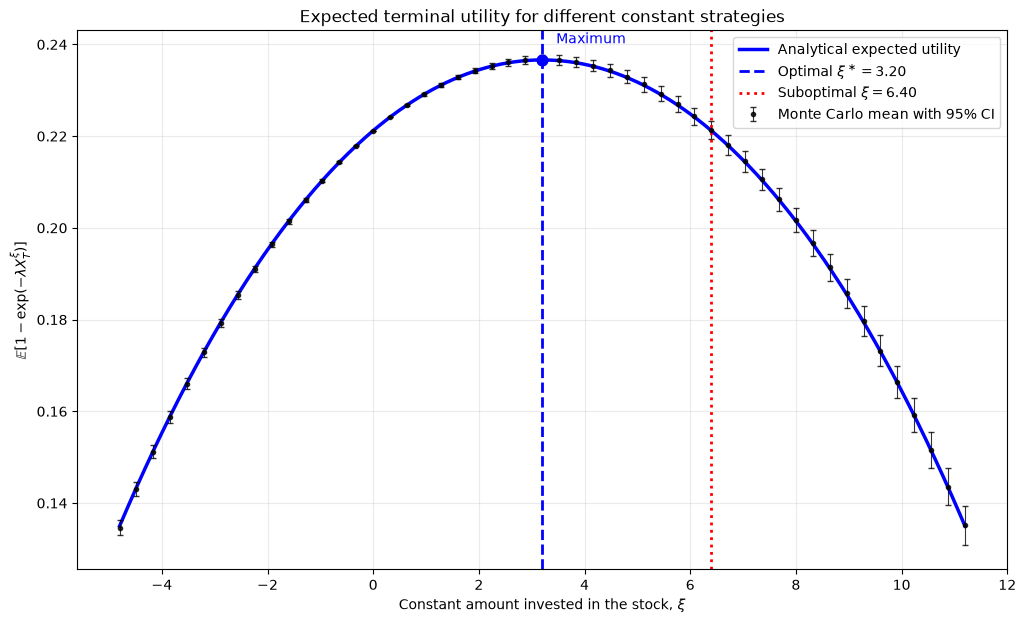

In [16]:
plot_expected_utility_mc(abs_risk_aversion=abs_risk_aversion, runs=100000, market_params=market)

### Comparison of the wealth processes

We now simulate the optimal strategy $\xi^\ast$ and a suboptimal constant strategy $\xi$.

Both simulations use the same random seed and therefore the same Brownian shocks. This makes differences between the strategies easier to identify because they are evaluated under identical market scenarios.

It is important to distinguish **expected optimality** from **pathwise dominance**. The optimal strategy does not produce higher wealth or higher utility on every individual path. Its defining property is

$$\mathbb E[U(X_T^{\xi^\ast})] \geq \mathbb E[U(X_T^\xi)]$$

for every admissible constant $\xi$.

Since $\xi^\ast$ also maximizes expected utility over every shorter horizon, its expected utility curve lies above that of any other constant strategy for all $t>0$. At $t=0$, the two curves coincide because both strategies start with the same initial wealth.

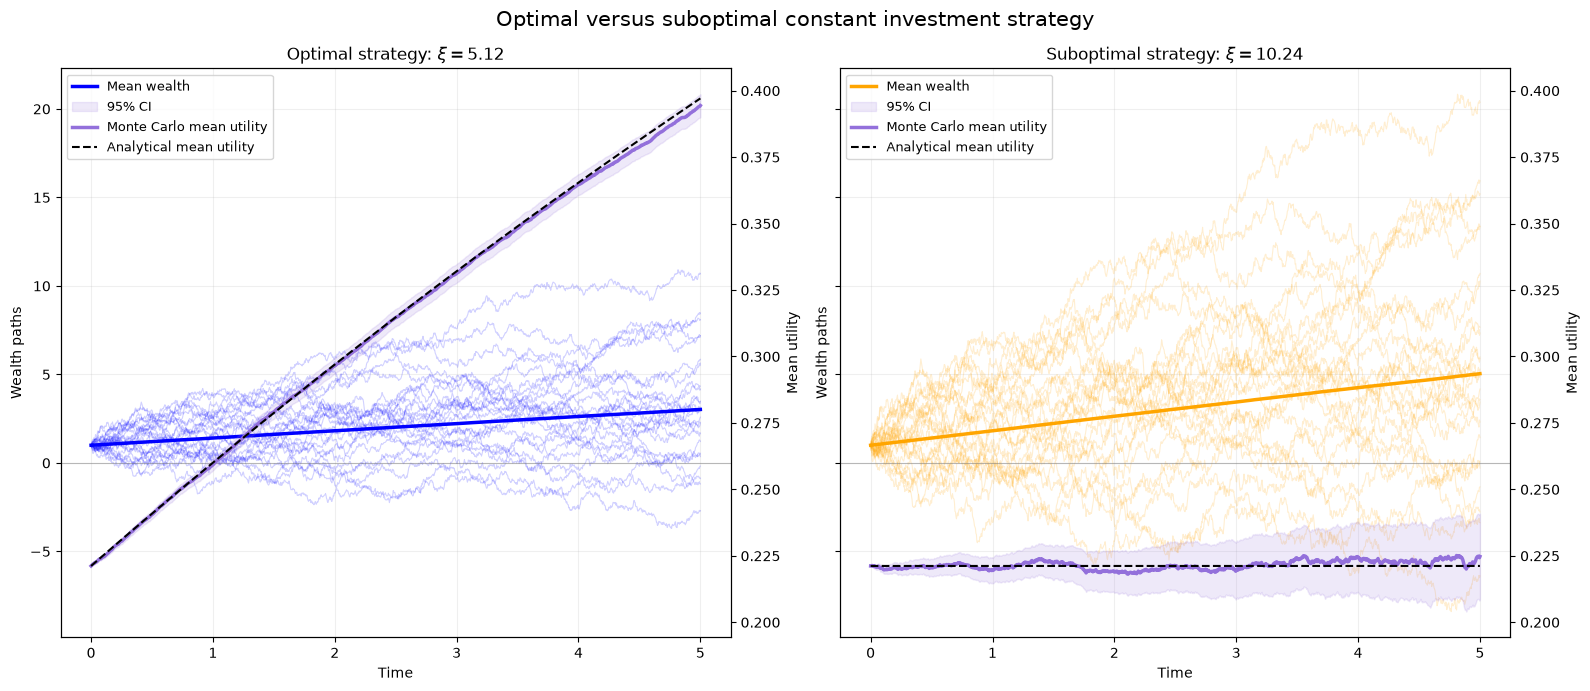

In [17]:
T = 5

market_params = FinancialMarket(risk_free_rate=0, risk_premium=0.08, volatility=0.25)
sde_params = SDESimulationParameters(time_horizon=T, time_steps=250*T, num_paths=50_000)

strategies = generate_strategies(simulate_wealth, abs_risk_aversion=0.25, market_params=market_params, sde_params=sde_params)

plot_strategies(strategies)

### Interpretation of the numerical results

The expected-utility plot confirms the analytical HJB result:

$$\xi^\ast = \frac{b}{\lambda\sigma^2}.$$

The analytical curve attains its unique maximum at $\xi^\ast$, while the Monte Carlo estimates fluctuate around that curve within their confidence intervals.

The wealth-path comparison also illustrates why the optimal strategy cannot be identified by looking only at average wealth. A larger value of $\xi$ increases both expected wealth and risk. Exponential utility penalizes the additional downside risk, so the strategy with the largest expected wealth need not have the largest expected utility.

The optimal strategy balances the stock's expected return against its variance and the investor's absolute risk aversion:

- a larger drift $b$ increases the optimal stock investment;
- a larger variance $\sigma^2$ reduces it;
- a larger risk-aversion parameter $\lambda$ also reduces it.

The strategy is optimal within the unconstrained model, but its constant monetary exposure can lead to negative wealth and unrealistic leverage when wealth becomes small.

## Exercise 3

Calculate the optimal portfolio and consumption strategy in the log utility case in the martingale method.

### Log-utility and the martingale method

We consider the horizon $T=1$ and the problem

$$\max_{(\pi,c) \in \mathcal{A}'(x)} \mathbb{E}\left[ \log X(1) + \int_0^1\log c(t) \,\mathrm{d}t \right] .$$

Here $\pi_i(t)$ is the **fraction of wealth** invested in stock $i$. The state-price density given by the slides is

$$H(t) = \exp\left[ -\left( r + \frac{1}{2}\|\theta\|^2 \right)t - \theta^\top W(t)\right], \qquad \theta = \sigma^{-1}(b - r\mathbf{1}) .$$

### 1. Optimal consumption and terminal wealth

For

$$U_2(x) = \log x, \qquad U_1(t,c) = \log c, $$

the marginal utilities and their inverses are

$$U_2'(x)=\frac{1}{x}, \qquad U_1'(t,c) = \frac{1}{c}, \qquad I_2(y) = I_1(t,y) = \frac{1}{y} .$$

Thus,

$$\begin{aligned}
\xi(y) &= \mathbb{E}\left[ H(1)I_2(yH(1)) + \int_0^1 H(t)I_1(t,yH(t)) \,\mathrm{d}t \right]\\
       &= \mathbb{E}\left[ H(1)\frac{1}{yH(1)} + \int_0^1 H(t)\frac{1}{yH(t)} \,\mathrm{d}t \right]\\
    &= \frac{1}{y} + \int_0^1\frac{1}{y} \,\mathrm{d}t = \frac{2}{y}.
\end{aligned}$$

The multiplier $\Upsilon(x) = \xi^{-1}(x)$ is therefore determined by

$$\boxed{\Upsilon(x) = \frac{2}{x} .}$$

The theorem on slide 24 now gives the optimal terminal wealth

$$\boxed{B^\ast = X^\ast(1) = I_2(\Upsilon(x)H(1)) = \frac{x}{2H(1)}}$$

and the optimal consumption rate

$$\boxed{c^\ast(t) = I_1(t,\Upsilon(x)H(t)) = \frac{x}{2H(t)}, \qquad 0 \leq t \leq 1.}$$

The budget is split equally — in state-price units — between terminal wealth and lifetime consumption:

$$\mathbb{E}[H(1)B^\ast] = \frac{x}{2}, \qquad \mathbb{E}\left[ \int_0^1 H(t)c^\ast(t) \,\mathrm{d}t \right] = \frac{x}{2} .$$

### 2. Optimal wealth process

At time $t$, the wealth needed to finance the remaining consumption and terminal payoff is

$$X^\ast(t) = \frac1{H(t)}\mathbb{E}_t\left[ H(1)B^\ast + \int_t^1 H(s)c^\ast(s) \,\mathrm{d}s \right].$$

Since

$$H(1)B^\ast = \frac{x}{2}, \qquad H(s)c^\ast(s) = \frac{x}{2} ,$$

we obtain

$$\boxed{X^\ast(t) = \frac{x(2-t)}{2H(t)}, \qquad 0 \leq t \leq 1 .}$$

In particular,

$$\boxed{c^\ast(t) = \frac{X^\ast(t)}{2-t} .}$$

Thus the investor consumes the fraction $1/(2-t)$ of current wealth per unit of time.

### 3. Optimal portfolio process

The state-price density satisfies

$$\frac{\mathrm{d}H(t)}{H(t)} = -r \,\mathrm{d}t - \theta^\top \mathrm{d}W(t) .$$

Using $X^\ast(t) = x(2-t)/(2H(t))$, Itô's formula therefore gives

$$\frac{\mathrm{d}X^\ast(t)}{X^\ast(t)} = \left( r + \|\theta\|^2 - \frac{1}{2-t} \right) \mathrm{d}t + \textcolor{red}{\theta^\top} \mathrm{d}W(t) .$$

On the other hand, the wealth equation in the slides' portfolio-fraction notation is

$$\frac{\mathrm{d}X(t)}{X(t)} = \left[ r + \pi(t)^\top(b - r \mathbf{1}) - \frac{c(t)}{X(t)} \right] \mathrm{d}t + \textcolor{red}{\pi(t)^\top\sigma} \,\mathrm{d}W(t) .$$

Because $c^\ast(t)/X^\ast(t) = 1/(2-t)$, comparison of the diffusion coefficients yields

$$\pi^\ast(t)^\top\sigma = \theta^\top = (\sigma^{-1}(b - r\mathbf{1}))^\top .$$

Consequently,

$$\boxed{\pi^\ast(t) = (\sigma\sigma^\top)^{-1}(b - r\mathbf{1}), \qquad 0 \leq t \leq 1 .}$$

This also matches the drift because

$$\pi^\ast(t)^\top(b - r\mathbf{1}) = \|\theta\|^2 .$$

Hence the log investor holds the constant growth-optimal **fractions** of wealth in the stocks. The amount invested in stock $i$ is $\pi_i^\ast X^\ast(t)$, and the corresponding number of shares is

$$\varphi_i^\ast(t) = \frac{\pi_i^\ast X^\ast(t)}{S_i(t)} .$$

### One-stock specialization

For one stock,

$$\boxed{\pi^\ast(t) = \frac{b - r}{\sigma^2}, \qquad c^\ast(t) = \frac{x}{2H(t)} = \frac{X^\ast(t)}{2-t}, \qquad X^\ast(t) = \frac{x(2-t)}{2H(t)} .}$$

If additionally $r=0$, the optimal portfolio strategy simply becomes $\pi^\ast(t) = b/\sigma^2$.

### Interpretation

- The investor allocates one half of the initial state-price budget to terminal wealth and one half to consumption over $[0,1]$.
- Consumption is state dependent: it is high when $H(t)$ is low, i.e. in states where wealth is relatively cheap in marginal-utility terms.
- The consumption-to-wealth rate rises from $1/2$ at $t=0$ to $1$ at $t=1$.
- The optimal stock fractions are constant and equal to the growth-optimal portfolio. Consumption changes the wealth path, but it does not change the log investor's optimal risky fractions.

### Graphical illustration of the log-optimal strategy

The explicit solution allows us to visualize the optimal strategy without solving another numerical optimization problem.

For the one-stock case,

$$H(t) = \exp\left[ - \left( r + \frac{1}{2}\theta^2 \right)t - \theta W(t) \right], \qquad \theta = \frac{b-r}{\sigma},$$

and

$$X^\ast(t) = \frac{x(2-t)}{2H(t)}, \qquad c^\ast(t) = \frac{x}{2H(t)}.$$

Both wealth and consumption therefore react to the same state-price-density shocks. Their ratio, however, is deterministic:

$$\frac{c^\ast(t)}{X^\ast(t)} = \frac{1}{2-t}.$$

At the same time, the fraction invested in the stock remains constant:

$$\pi^\ast = \frac{b-r}{\sigma^2}.$$

The following figure illustrates these three properties.

In [18]:
def generate_deflator_H(market_params: FinancialMarket, sde_params: SDESimulationParameters) -> SDEOutput:
    """
    Generate a state-price deflator H(t) for the given market parameters and SDE simulation parameters.
    """

    # Simulate Brownian motion
    brownian = generate_brownian_path(mu=0, sigma=1, params=sde_params)

    t = brownian.time_grid
    W = brownian.paths["W"]

    # Market price of risk and state-price density
    theta = market_params.risk_premium / market_params.volatility

    H = np.exp(
        -(market_params.risk_free_rate + 0.5 * theta**2) * t[:, np.newaxis]
        -theta * W
    )

    return SDEOutput(time_grid=t, paths={'H': H})

Optimal stock fraction: 65.31%


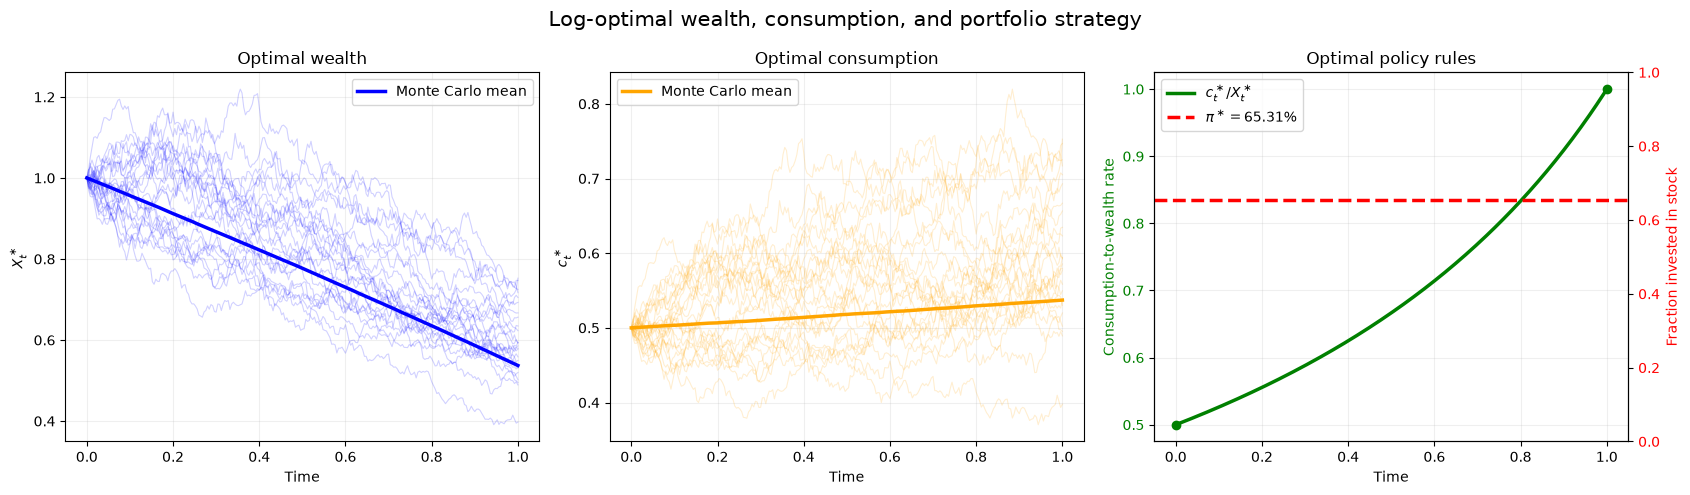

In [19]:
# Model and simulation parameters
market     = FinancialMarket(risk_free_rate=0.02, risk_premium=0.08, volatility=0.35)
sde_params = SDESimulationParameters(time_horizon=1, time_steps=250, num_paths=20_000)

plot_wealth_consumption_policy(generate_deflator_H, market, sde_params)

### Interpretation

The figure highlights the main properties of the log-optimal strategy:

- Wealth and consumption move in the same direction because both are proportional to $1/H(t)$.
- The consumption-to-wealth rate is deterministic and increases from

  $$\frac{c^\ast(0)}{X^\ast(0)} = \frac{1}{2}$$

  to

  $$\frac{c^\ast(1)}{X^\ast(1)} = 1 .$$

- The fraction invested in the stock remains constant:

  $$\pi^\ast=\frac{b-r}{\sigma^2} = \frac{\lambda}{\sigma^2} .$$

- For the chosen parameters ($\lambda=0.08$, $\sigma=0.35$), the investor continuously holds $65.31\%$ of wealth in the stock.
- In state-price units, exactly one half of initial wealth finances terminal wealth and the other half finances consumption over $[0,1]$.

Thus consumption changes relative to wealth as the horizon approaches, while the log-optimal risky fraction is unaffected by the remaining time.